# 02_Burgers_Equation

## Learning Goal
Solving Burgers' Equation practically.

## Prerequisites
Basic understanding of Calculus and Neural Networks.

## Theory & Mathematics
(Mathematical derivations and fundamental concepts)

## Implementation & Experiments


In [14]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [18]:
def loss_fn(model, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f, nu=0.01/np.pi):
    # Initial Condition Loss
    u_pred_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic)**2)
    
    # Boundary Condition Loss
    u_pred_bc = model(x_bc, t_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)
    
    # Physics Residual Loss (Burgers' Equation)
    u_pred_f, u_t, u_x, u_xx = compute_derivatives(model, x_f, t_f)
    residual = u_t + u_pred_f * u_x - nu * u_xx
    loss_pde = torch.mean(residual**2)
    
    return loss_ic, loss_bc, loss_pde

In [19]:
def generate_data(N_ic=200, N_bc=200, N_f=10000):
    # Initial condition: t=0, x in [-1,1]
    x_ic = torch.rand(N_ic, 1, device=device) * 2 - 1
    t_ic = torch.zeros(N_ic, 1, device=device)
    u_ic = -torch.sin(np.pi * x_ic)
    
    # Boundary conditions: x=-1 and x=1, t in [0,1]
    t_bc = torch.rand(N_bc, 1, device=device)
    x_bc = torch.where(torch.rand_like(t_bc) < 0.5, 
                       -torch.ones_like(t_bc), torch.ones_like(t_bc))
    u_bc = torch.zeros(N_bc, 1, device=device)
    
    # Collocation points
    x_f = torch.rand(N_f, 1, device=device) * 2 - 1
    t_f = torch.rand(N_f, 1, device=device)
    
    return x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f

In [20]:
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, x_f, t_f = generate_data()

loss_history = {'ic': [], 'bc': [], 'pde': [], 'total': []}

print("Starting training...")
for epoch in range(5000):
    optimizer.zero_grad()
    
    loss_ic, loss_bc, loss_pde = loss_fn(model, x_ic, t_ic, u_ic, 
                                         x_bc, t_bc, u_bc, 
                                         x_f, t_f)
    
    # Unweighted sum (we will critique this later)
    total_loss = loss_ic + loss_bc + loss_pde
    total_loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        loss_history['ic'].append(loss_ic.item())
        loss_history['bc'].append(loss_bc.item())
        loss_history['pde'].append(loss_pde.item())
        loss_history['total'].append(total_loss.item())
        print(f"Epoch {epoch:4d} | IC: {loss_ic.item():.4f} | BC: {loss_bc.item():.4f} | PDE: {loss_pde.item():.4f} | Total: {total_loss.item():.4f}")


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch    0 | IC: 0.5658 | BC: 0.0064 | PDE: 0.0002 | Total: 0.5723
Epoch  500 | IC: 0.0634 | BC: 0.0033 | PDE: 0.0485 | Total: 0.1152
Epoch 1000 | IC: 0.0402 | BC: 0.0005 | PDE: 0.0318 | Total: 0.0725
Epoch 1500 | IC: 0.0158 | BC: 0.0003 | PDE: 0.0128 | Total: 0.0289
Epoch 2000 | IC: 0.0088 | BC: 0.0002 | PDE: 0.0178 | Total: 0.0268
Epoch 2500 | IC: 0.0035 | BC: 0.0001 | PDE: 0.0036 | Total: 0.0072
Epoch 3000 | IC: 0.0020 | BC: 0.0000 | PDE: 0.0022 | Total: 0.0041
Epoch 3500 | IC: 0.0059 | BC: 0.0004 | PDE: 0.1064 | Total: 0.1126
Epoch 4000 | IC: 0.0009 | BC: 0.0000 | PDE: 0.0011 | Total: 0.0020
Epoch 4500 | IC: 0.0006 | BC: 0.0000 | PDE: 0.0008 | Total: 0.0014


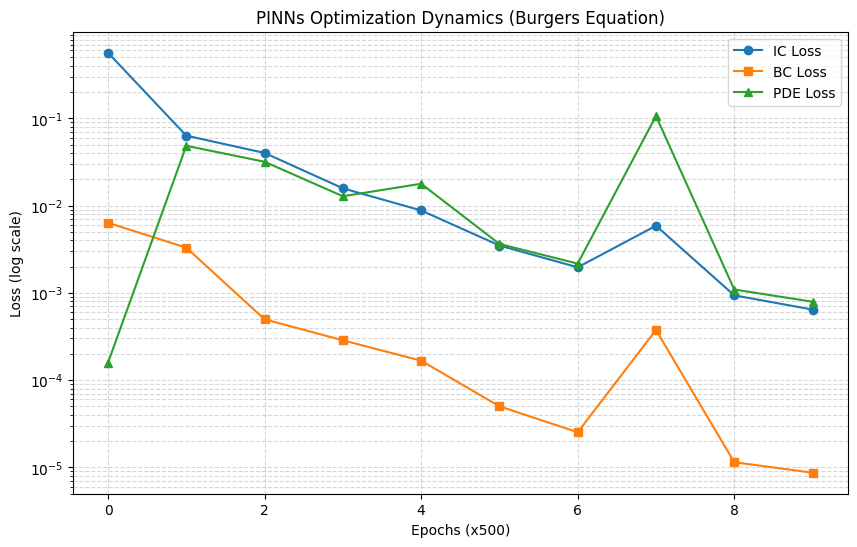

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history['ic'], label='IC Loss', marker='o')
plt.plot(loss_history['bc'], label='BC Loss', marker='s')
plt.plot(loss_history['pde'], label='PDE Loss', marker='^')
plt.yscale('log')
plt.xlabel('Epochs (x500)')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.title('PINNs Optimization Dynamics (Burgers Equation)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Summary
This experiment demonstrates the specific concept in action.

## Further Reading
- Scientific Machine Learning & PINN surveys.